In [ ]:
import numpy as np
import math 
import matplotlib.pyplot as plt

def HestonEuropeanRecursive(S0, K, Nsteps, T, r, q, v0, rho, kappa, epsilon, theta, dt, t, i):
    Z1, Z2 = np.random.normal(0, 1, 1), np.random.normal(0, 1, 1)

    Z = rho * Z1 + math.sqrt(1 - rho**2) * Z2

    v0 = v0 + kappa * (theta - v0) * dt + epsilon * math.sqrt(v0 * dt) * Z
    v0 = max(v0, 0)

    S = math.exp(math.log(S0) + (r - q - 1/2 * v0) * dt + math.sqrt(v0 * dt) * Z1)

    t = t + dt

    if t < T:
        return HestonEuropeanRecursive(S, K, Nsteps, T, r, q, v0, rho, kappa, epsilon, theta, dt, t, i)

    return S


def MonteCarlo(S0, K, Npaths, Nsteps, T, r, q, v0, rho, kappa, epsilon, theta, C0, dt, t, i):
    for p in range(0, Npaths):
        C0 = C0 + math.exp(-r * T) * max(i * (HestonEuropeanRecursive(S0, K, Nsteps, T, r, q, v0, rho, kappa, epsilon, theta, dt, t, i) - K), 0) / Npaths
    return C0


In [ ]:

S0 = 100
r  = 0.02
q  = 0.00

kappa = 2.0
epsilon = 0.5
rho = -0.7
v0 = 0.04
theta = 0.04   # negative spot-vol correlation -> skew

Nsteps = 200    
Npaths = 10000      

Ks = np.array([70, 75, 80, 85,90, 95, 100, 105, 110])
Ts = np.array([0.25,0.5,0.75, 1.0, 1.25,1.5,1.75,2])  

C = np.zeros((len(Ts), len(Ks)))

for a, T in enumerate(Ts):
    dt = T / Nsteps
    for b, K in enumerate(Ks):
        C[a, b] = MonteCarlo(
            S0, K, Npaths, Nsteps, T,
            r, q, v0, rho, kappa, epsilon, theta,
            C0=0.0, dt=dt, t=0.0,i=1
        )

In [3]:


def norm_cdf(x):                                                       # CDF of the normal distribution
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_call_price(S0, K, T, r, q, sigma):
    if T <= 0.0:                                                       # The option is at maturity, so its price is the immediate payoff
        return max(S0 - K, 0.0)

    if sigma <= 0.0:                                                   # Negative volatility, so the future price is deterministic
        F = S0 * math.exp((r - q) * T)
        return math.exp(-r * T) * max(F - K, 0.0)

    sqrtT = math.sqrt(T)                                             
    d1 = (math.log(S0 / K) + (r - q + 0.5 * sigma * sigma) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT

    return (S0 * math.exp(-q * T) * norm_cdf(d1)
            - K  * math.exp(-r * T) * norm_cdf(d2))                  

def implied_vol_call_bisect_safe(price, S0, K, T, r, q,
                                 tol=1e-6, max_iter=200,
                                 sigma_lo=1e-8, sigma_hi=3.0,
                                 clip_eps=1e-12):


    price = float(np.squeeze(price))
    discS = S0 * math.exp(-q * T)
    discK = K  * math.exp(-r * T)
    lower = max(0.0, discS - discK)   
    upper = discS                           # No-arbitrage bounds for the call


    if price < lower:
        price = max(price, lower + clip_eps)
    if price > upper:
        price = min(price, upper - clip_eps)      # We check that the target price (from Heston/MC or from the market) is compatible
                                                  # with a Black–Scholes price for the same parameters (S0, K, T, r, q)!

    lo, hi = sigma_lo, sigma_hi
  
    while bs_call_price(S0, K, T, r, q, hi) < price:      # Therefore, to run a bisection method, we need an upper bound.
        hi *= 2.0
        if hi > 20.0:

            return float("nan")

# Now we perform the bisection method
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        cmid = bs_call_price(S0, K, T, r, q, mid)

        if abs(cmid - price) < tol:
            return mid
        if cmid < price:
            lo = mid
        else:
            hi = mid

    return 0.5 * (lo + hi)


In [4]:
IV = np.zeros_like(C)

for a, T in enumerate(Ts):
    for b, K in enumerate(Ks):
        IV[a, b] = implied_vol_call_bisect_safe(C[a, b], S0, K, T, r, q)

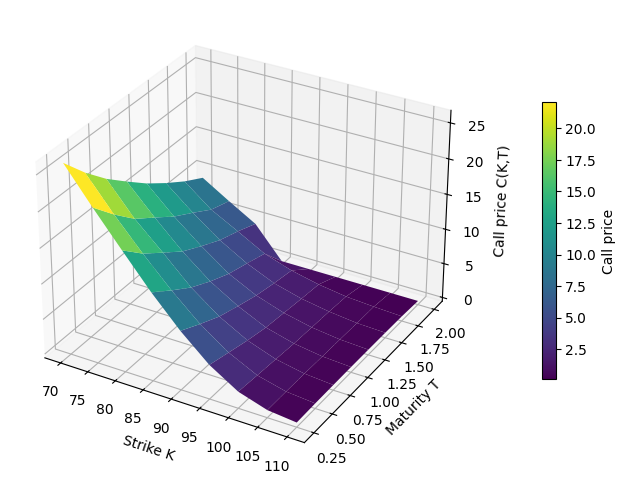

In [5]:
import os

os.makedirs("figures", exist_ok=True)

K_grid, T_grid = np.meshgrid(Ks, Ts)

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(K_grid, T_grid, C, cmap="viridis")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="Call price")

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T")
ax.set_zlabel("Call price C(K,T)")


plt.show()

Ts sorted desc: [2.   1.75 1.5  1.25 1.   0.75 0.5  0.25]


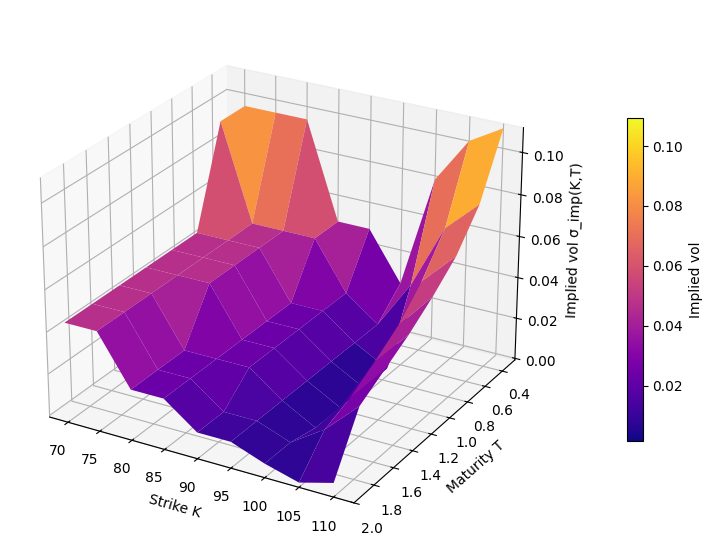

In [6]:
from matplotlib.colors import Normalize

idx = np.argsort(Ts)[::-1]
Ts_desc = Ts[idx]
IV_desc = IV[idx, :]

print("Ts sorted desc:", Ts_desc) 

K_grid, T_grid = np.meshgrid(Ks, Ts_desc)

norm = Normalize(vmin=np.nanmin(IV_desc), vmax=np.nanmax(IV_desc))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(K_grid, T_grid, IV_desc, cmap="plasma", norm=norm)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="Implied vol")

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T")
ax.set_zlabel("Implied vol σ_imp(K,T)")

ax.set_ylim(Ts_desc.min(), Ts_desc.max())
ax.invert_yaxis()            
ax.view_init(elev=25, azim=-60)



plt.show()

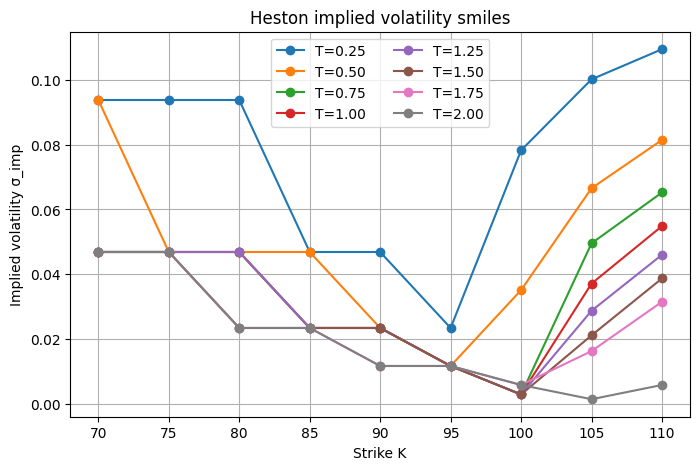

In [7]:
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8,5))
for a, T in enumerate(Ts):
    plt.plot(Ks, IV[a, :], marker="o", label=f"T={T:.2f}")

plt.xlabel("Strike K")
plt.ylabel("Implied volatility σ_imp")
plt.title("Heston implied volatility smiles")
plt.grid(True)
plt.legend(ncol=2)

plt.show()

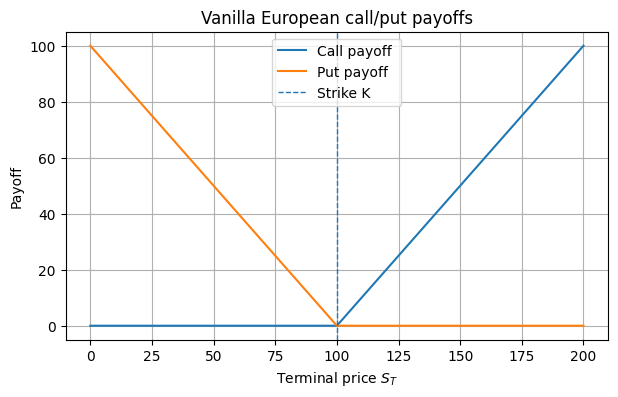

In [8]:
K = 100
S_min, S_max = 0, 200
n_points = 1000


S = np.linspace(S_min, S_max, n_points)
call = np.maximum(S - K, 0.0)
put  = np.maximum(K - S, 0.0)


plt.figure(figsize=(7, 4))
plt.plot(S, call, label="Call payoff ")
plt.plot(S, put,  label="Put payoff ")
plt.axvline(K, linestyle="--", linewidth=1, label="Strike K")

plt.xlabel("Terminal price $S_T$")
plt.ylabel("Payoff")
plt.title("Vanilla European call/put payoffs")
plt.legend()
plt.grid(True)


plt.show()